In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
import pickle
from astropy.io import fits 
%matplotlib widget 


plt.rcParams['font.family'] = 'DejaVu Sans Mono'   # Replace 'DejaVu Sans Mono', DejaVu Serif with your preferred font
plt.rcParams['font.size'] = 12          # Set font size
plt.rcParams['axes.titlesize'] = 14     # Title font size
plt.rcParams['axes.labelsize'] = 10     # Axes label font size
plt.rcParams['legend.fontsize'] = 10    # Legend font size
plt.rcParams['xtick.labelsize'] = 10    # X-axis tick font size
plt.rcParams['ytick.labelsize'] = 10    # Y-axis tick font size


science_list = np.genfromtxt('./group15_WASP-12_20191229/science/science.list', dtype=str)
science_test_list = science_list[:10]
science_frame_name = './group15_WASP-12_20191229/correct/' + science_test_list[0][:-5] + '_corr.p'
science_corrected =    pickle.load(open(science_frame_name, 'rb'))

vmin:  857.9    vmax: 80367.5


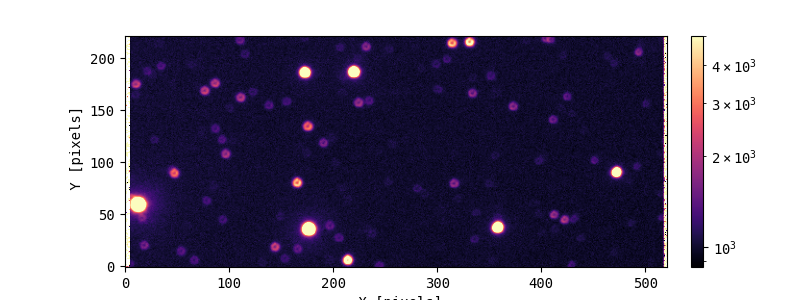

In [2]:
import matplotlib.colors as colors

vmin = np.amin(science_corrected[:,100:400])
vmax = np.amax(science_corrected[:,100:400])
print('vmin:  {0:.1f}    vmax: {1:.1f}'.format(vmin, vmax))
vmax = 5000

fig, ax = plt.subplots(1, figsize=(8,3))
im1 = plt.imshow(science_corrected, cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax), origin='lower')
plt.colorbar(im1,ax=ax, fraction=0.046, pad=0.04)
plt.xlabel(' X [pixels]')
plt.ylabel(' Y [pixels]')
plt.show()

In [3]:
x_target = 357
y_target = 37

x_reference_01 = 172
y_reference_01 = 186

x_reference_02 = 472
y_reference_02 = 90

vmin:  857.9    vmax: 80367.5


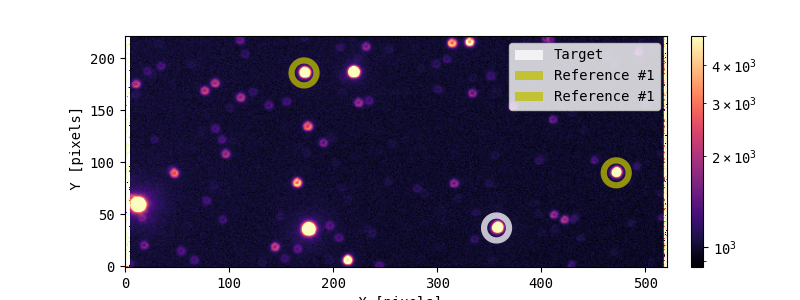

In [4]:
def make_ring_around_star(x_pos, y_pos, label='', color='w'):
    from matplotlib.patches import Circle

    n, radii = 50, [9, 15]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=0.75, label=label)



vmin = np.amin(science_corrected[:,100:400])
vmax = np.amax(science_corrected[:,100:400])
print('vmin:  {0:.1f}    vmax: {1:.1f}'.format(vmin, vmax))
vmax = 5000

fig, ax = plt.subplots(1, figsize=(8,3))
im1 = plt.imshow(science_corrected, cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax), origin='lower')
plt.colorbar(im1,ax=ax, fraction=0.046, pad=0.04)

make_ring_around_star(x_target, y_target, label='Target', color='w')
make_ring_around_star(x_reference_01, y_reference_01, label='Reference #1', color='y')
make_ring_around_star(x_reference_02, y_reference_02, label='Reference #1', color='y')
plt.xlabel(' X [pixels]')
plt.ylabel(' Y [pixels]')
ax.legend()
plt.show()

In [5]:
ylen, xlen  = np.shape(science_corrected)
print('Shape of our science frame: {0:d} x {1:d}'.format(xlen, ylen))
X_axis = np.arange(0, xlen, 1)
Y_axis = np.arange(0, ylen, 1)
X, Y = np.meshgrid(X_axis, Y_axis)

Shape of our science frame: 521 x 222


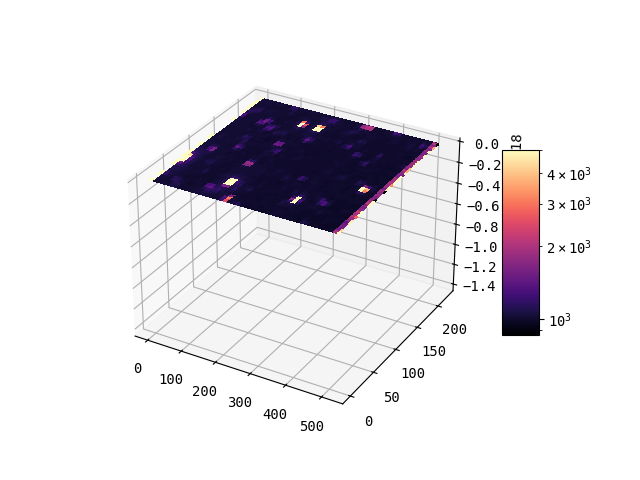

In [6]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
surf = ax.plot_surface(X, Y, science_corrected, cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax),
                       linewidth=0, antialiased=False)

## Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

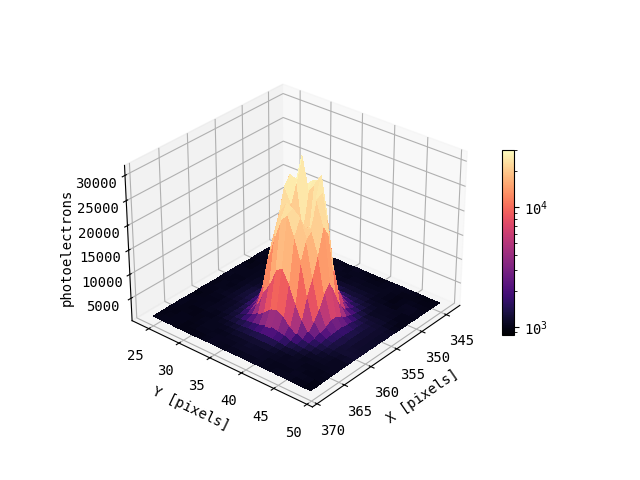

In [7]:
vmax= 30000
radius_plot = 13


fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
surf = ax.plot_surface(X[y_target-radius_plot:y_target+radius_plot, x_target-radius_plot:x_target+radius_plot],
                       Y[y_target-radius_plot:y_target+radius_plot, x_target-radius_plot:x_target+radius_plot],
                       science_corrected[y_target-radius_plot:y_target+radius_plot, x_target-radius_plot:x_target+radius_plot],
                       cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax),
                       linewidth=0, antialiased=False)

# Force rotation of the plot to get the numbers on the left side
# You can get the azimuth and elevation of the observer on the lower part of the plot
# when rotating the image
ax.azim = 40 # value in degree
ax.elev = 30 # value in degree

ax.set_xlabel('X [pixels]')
ax.set_ylabel('Y [pixels]')

# Fix the orientation fo the Z label
ax.zaxis.set_rotate_label(False)  # disable automatic rotation
ax.set_zlabel('photoelectrons', rotation=90)

## Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=15, ticks=[10, 100, 1000, 10000, 100000])

plt.show()

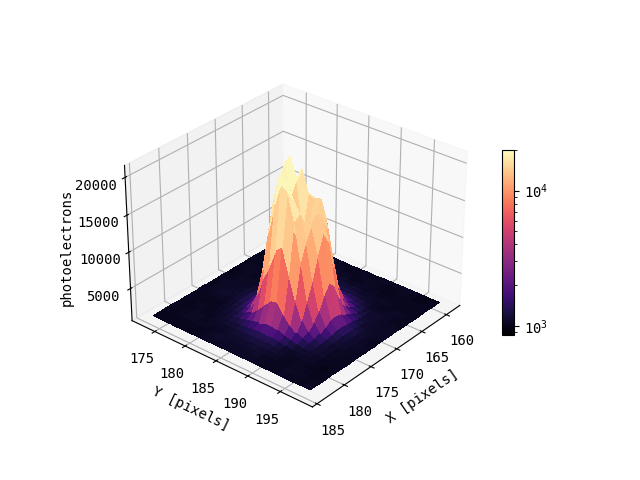

In [8]:
vmax= 20000
radius_plot = 13


fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
surf = ax.plot_surface(X[y_reference_01-radius_plot:y_reference_01+radius_plot, x_reference_01-radius_plot:x_reference_01+radius_plot],
                       Y[y_reference_01-radius_plot:y_reference_01+radius_plot, x_reference_01-radius_plot:x_reference_01+radius_plot],
                       science_corrected[y_reference_01-radius_plot:y_reference_01+radius_plot, x_reference_01-radius_plot:x_reference_01+radius_plot],
                       cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax),
                       linewidth=0, antialiased=False)

# Force rotation of the plot to get the numbers on the left side
# You can get the azimuth and elevation of the observer on the lower part of the plot
# when rotating the image
ax.azim = 40 # value in degree
ax.elev = 30 # value in degree

ax.set_xlabel('X [pixels]')
ax.set_ylabel('Y [pixels]')

# Fix the orientation fo the Z label
ax.zaxis.set_rotate_label(False)  # disable automatic rotation
ax.set_zlabel('photoelectrons', rotation=90)

## Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=15, ticks=[10, 100, 1000, 10000, 100000])

plt.show()

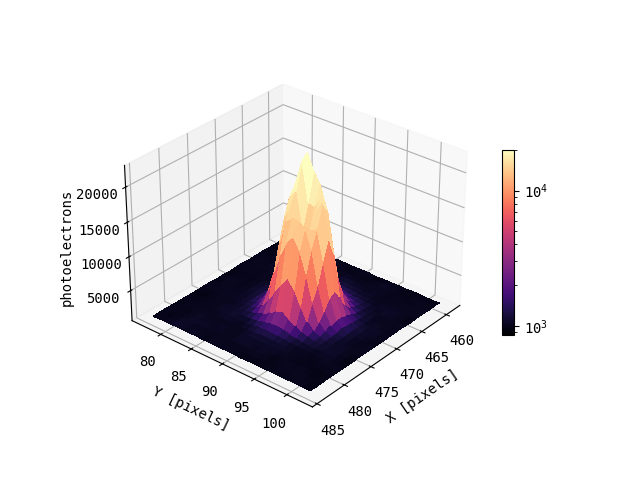

In [9]:
vmax= 20000
radius_plot = 13


fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
surf = ax.plot_surface(X[y_reference_02-radius_plot:y_reference_02+radius_plot, x_reference_02-radius_plot:x_reference_02+radius_plot],
                       Y[y_reference_02-radius_plot:y_reference_02+radius_plot, x_reference_02-radius_plot:x_reference_02+radius_plot],
                       science_corrected[y_reference_02-radius_plot:y_reference_02+radius_plot, x_reference_02-radius_plot:x_reference_02+radius_plot],
                       cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax),
                       linewidth=0, antialiased=False)

# Force rotation of the plot to get the numbers on the left side
# You can get the azimuth and elevation of the observer on the lower part of the plot
# when rotating the image
ax.azim = 40 # value in degree
ax.elev = 30 # value in degree

ax.set_xlabel('X [pixels]')
ax.set_ylabel('Y [pixels]')

# Fix the orientation fo the Z label
ax.zaxis.set_rotate_label(False)  # disable automatic rotation
ax.set_zlabel('photoelectrons', rotation=90)

## Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=15, ticks=[10, 100, 1000, 10000, 100000])

plt.show()

In [10]:
import time

t0 = time.time()

print('Seconds passed since January 1, 1970, 00:00:00 (UTC): {0:.4f}'.format(t0))

t1 = time.time()

delta_time = t1 - t0
print('Time spent to print the previous information: {0:f} seconds'.format(delta_time))

Seconds passed since January 1, 1970, 00:00:00 (UTC): 1738005708.3495
Time spent to print the previous information: 0.000136 seconds


In [11]:
t0 = time.time()

rr_method01 = np.zeros_like(science_corrected)
for yi in range(0,np.shape(science_corrected)[0]):
    for xi in range (0, np.shape(science_corrected)[1]):
        rr_method01[yi, xi] =  np.sqrt((xi-x_target)**2 + (yi-y_target)**2)

t1 = time.time()

total_method01 = t1-t0
print('Time required by the first method: {0:f} seconds'.format(total_method01))

Time required by the first method: 0.411344 seconds


In [12]:
t0 = time.time()

X_axis = np.arange(0, xlen, 1)
Y_axis = np.arange(0, ylen, 1)
X, Y = np.meshgrid(X_axis, Y_axis)

t1 = time.time()

rr_method02 = np.sqrt((X-x_target)**2 + (Y-y_target)**2)

t2 = time.time()

prepare_method02 = t1-t0
total_method02 = t2-t1
print('Time required to set up the second algorithm: {0:f} seconds'.format(prepare_method02))
print('Time required by second algorithm:            {0:f} seconds'.format(total_method02))

Time required to set up the second algorithm: 0.005177 seconds
Time required by second algorithm:            0.004686 seconds


In [13]:
print('Algorithm using meshgrid is {0:.0f} times faster'.format(total_method01/total_method02))


Algorithm using meshgrid is 88 times faster


In [15]:
target_inner_radius = 13

# Computing again the meshgrid arrays 
ylen, xlen = np.shape(science_corrected)
X_axis = np.arange(0, xlen, 1)
Y_axis = np.arange(0, ylen, 1)
X, Y = np.meshgrid(X_axis, Y_axis)

# 2D array with the distance of each pixel from the target star 
target_distance = np.sqrt((X-x_target)**2 + (Y-y_target)**2)

# Selection of the pixels within the inner radius
target_annulus_sel = (target_distance < target_inner_radius)

# Weighted sum of coordinates
target_weighted_X = np.sum(science_corrected[target_annulus_sel]*X[target_annulus_sel])
target_weighted_Y = np.sum(science_corrected[target_annulus_sel]*Y[target_annulus_sel])

# Sum of the weights
target_total_flux = np.sum(science_corrected[target_annulus_sel])

# Refined determination of coordinates
x_target_refined = target_weighted_X/target_total_flux
y_target_refined = target_weighted_Y/target_total_flux

print('Initial coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_target, y_target))
print('Refined coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_target_refined, y_target_refined))

Initial coordinates  x: 357.00   y: 37.00
Refined coordinates  x: 357.00   y: 37.48


In [16]:
reference_01_inner_radius = 12

# Computing again the meshgrid arrays 
ylen, xlen = np.shape(science_corrected)
X_axis = np.arange(0, xlen, 1)
Y_axis = np.arange(0, ylen, 1)
X, Y = np.meshgrid(X_axis, Y_axis)

# 2D array with the distance of each pixel from the reference_01 star 
reference_01_distance = np.sqrt((X-x_reference_01)**2 + (Y-y_reference_01)**2)

# Selection of the pixels within the inner radius
reference_01_annulus_sel = (reference_01_distance < reference_01_inner_radius)

# Weighted sum of coordinates
reference_01_weighted_X = np.sum(science_corrected[reference_01_annulus_sel]*X[reference_01_annulus_sel])
reference_01_weighted_Y = np.sum(science_corrected[reference_01_annulus_sel]*Y[reference_01_annulus_sel])

# Sum of the weights
reference_01_total_flux = np.sum(science_corrected[reference_01_annulus_sel])

# Refined determination of coordinates
x_reference_01_refined = reference_01_weighted_X/reference_01_total_flux
y_reference_01_refined = reference_01_weighted_Y/reference_01_total_flux

print('Initial coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_reference_01, y_reference_01))
print('Refined coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_reference_01_refined, y_reference_01_refined))

Initial coordinates  x: 172.00   y: 186.00
Refined coordinates  x: 172.16   y: 186.28


In [17]:
reference_02_inner_radius = 11

# Computing again the meshgrid arrays 
ylen, xlen = np.shape(science_corrected)
X_axis = np.arange(0, xlen, 1)
Y_axis = np.arange(0, ylen, 1)
X, Y = np.meshgrid(X_axis, Y_axis)

# 2D array with the distance of each pixel from the reference_02 star 
reference_02_distance = np.sqrt((X-x_reference_02)**2 + (Y-y_reference_02)**2)

# Selection of the pixels within the inner radius
reference_02_annulus_sel = (reference_02_distance < reference_02_inner_radius)

# Weighted sum of coordinates
reference_02_weighted_X = np.sum(science_corrected[reference_02_annulus_sel]*X[reference_02_annulus_sel])
reference_02_weighted_Y = np.sum(science_corrected[reference_02_annulus_sel]*Y[reference_02_annulus_sel])

# Sum of the weights
reference_02_total_flux = np.sum(science_corrected[reference_02_annulus_sel])

# Refined determination of coordinates
x_reference_02_refined = reference_02_weighted_X/reference_02_total_flux
y_reference_02_refined = reference_02_weighted_Y/reference_02_total_flux

print('Initial coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_reference_02, y_reference_02))
print('Refined coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_reference_02_refined, y_reference_02_refined))

Initial coordinates  x: 472.00   y: 90.00
Refined coordinates  x: 471.36   y: 90.40


vmin:  857.9    vmax: 80367.5


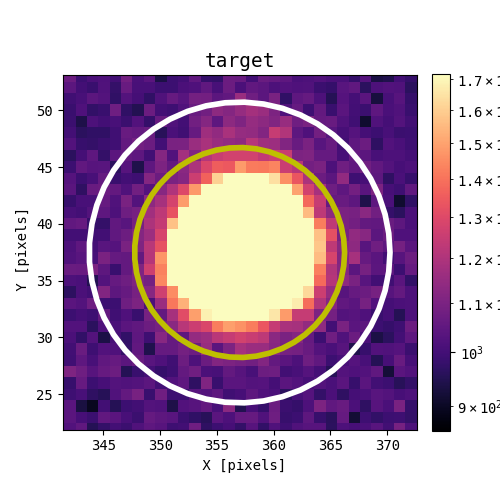

In [18]:
def make_circle_around_star(x_pos, y_pos, radius, thickness=0.5, label='', color='w', alpha=1.):
    from matplotlib.patches import Circle

    n, radii = 50, [radius, radius+thickness]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=alpha, label=label)


from matplotlib import colors 

vmin = np.amin(science_corrected[:,100:400])
vmax = np.amax(science_corrected[:,100:400])
print('vmin:  {0:.1f}    vmax: {1:.1f}'.format(vmin, vmax))
vmax = 2*vmin

fig, ax = plt.subplots(1, figsize=(5,5))
im1 = plt.imshow(science_corrected, cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax), origin='lower')
plt.colorbar(im1,ax=ax, fraction=0.046, pad=0.04)

# Cut the plot around the target star, with some margin with respect to the inner radius
plt.xlim(x_target_refined-target_inner_radius*1.2, x_target_refined+target_inner_radius*1.2)
plt.ylim(y_target_refined-target_inner_radius*1.2, y_target_refined+target_inner_radius*1.2)

make_circle_around_star(x_target_refined, y_target_refined, target_inner_radius, label='Good inner radius')
make_circle_around_star(x_target_refined, y_target_refined, 9, color='y', label='Bad inner radius')

plt.xlabel(' X [pixels]')
plt.ylabel(' Y [pixels]')
plt.title('target')
#plt.legend(loc='upper left')
plt.show()

vmin:  857.9    vmax: 80367.5


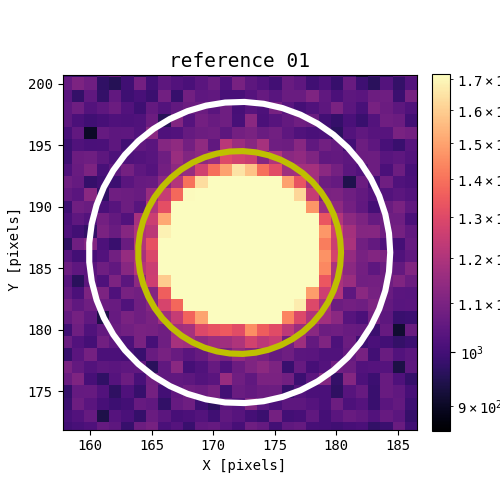

In [19]:
def make_circle_around_star(x_pos, y_pos, radius, thickness=0.5, label='', color='w', alpha=1.):
    from matplotlib.patches import Circle

    n, radii = 50, [radius, radius+thickness]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=alpha, label=label)


from matplotlib import colors 

vmin = np.amin(science_corrected[:,100:400])
vmax = np.amax(science_corrected[:,100:400])
print('vmin:  {0:.1f}    vmax: {1:.1f}'.format(vmin, vmax))
vmax = 2*vmin

fig, ax = plt.subplots(1, figsize=(5,5))
im1 = plt.imshow(science_corrected, cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax), origin='lower')
plt.colorbar(im1,ax=ax, fraction=0.046, pad=0.04)

# Cut the plot around the reference_01 star, with some margin with respect to the inner radius
plt.xlim(x_reference_01_refined-reference_01_inner_radius*1.2, x_reference_01_refined+reference_01_inner_radius*1.2)
plt.ylim(y_reference_01_refined-reference_01_inner_radius*1.2, y_reference_01_refined+reference_01_inner_radius*1.2)

make_circle_around_star(x_reference_01_refined, y_reference_01_refined, reference_01_inner_radius, label='Good inner radius')
make_circle_around_star(x_reference_01_refined, y_reference_01_refined, 8, color='y', label='Bad inner radius')

plt.xlabel(' X [pixels]')
plt.ylabel(' Y [pixels]')
#plt.legend(loc='upper left')
plt.title('reference 01')
plt.show()

vmin:  857.9    vmax: 80367.5


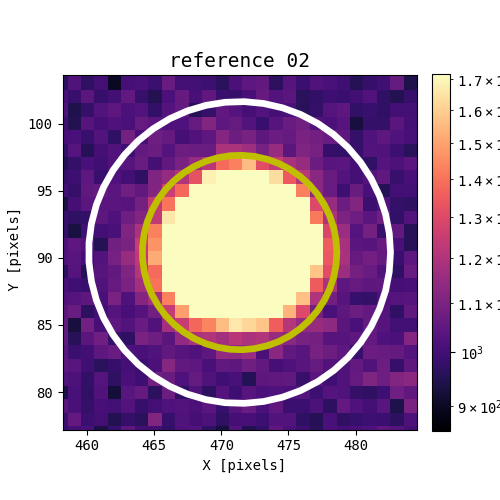

In [20]:
def make_circle_around_star(x_pos, y_pos, radius, thickness=0.5, label='', color='w', alpha=1.):
    from matplotlib.patches import Circle

    n, radii = 50, [radius, radius+thickness]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=alpha, label=label)


from matplotlib import colors 

vmin = np.amin(science_corrected[:,100:400])
vmax = np.amax(science_corrected[:,100:400])
print('vmin:  {0:.1f}    vmax: {1:.1f}'.format(vmin, vmax))
vmax = 2*vmin

fig, ax = plt.subplots(1, figsize=(5,5))
im1 = plt.imshow(science_corrected, cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax), origin='lower')
plt.colorbar(im1,ax=ax, fraction=0.046, pad=0.04)

# Cut the plot around the reference_02 star, with some margin with respect to the inner radius
plt.xlim(x_reference_02_refined-reference_02_inner_radius*1.2, x_reference_02_refined+reference_02_inner_radius*1.2)
plt.ylim(y_reference_02_refined-reference_02_inner_radius*1.2, y_reference_02_refined+reference_02_inner_radius*1.2)

make_circle_around_star(x_reference_02_refined, y_reference_02_refined, reference_02_inner_radius, label='Good inner radius')
make_circle_around_star(x_reference_02_refined, y_reference_02_refined, 7, color='y', label='Bad inner radius')

plt.xlabel(' X [pixels]')
plt.ylabel(' Y [pixels]')
plt.title('reference 02')

#plt.legend(loc='upper left')
plt.show()

In [21]:
# Initial coordinates of the target
x_target_initial = 357
y_target_initial = 37

maximum_number_of_iterations = 30

# Computing again the meshgrid arrays 
#ylen, xlen = np.shape(science_corrected)
#X_axis = np.arange(0, xlen, 1)
#Y_axis = np.arange(0, ylen, 1)
#X, Y = np.meshgrid(X_axis, Y_axis)

print('Initial coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_target_initial, y_target_initial))

for i_iter in range(0, maximum_number_of_iterations):

    if i_iter == 0:
        # first iteration
        x_target_previous = x_target_initial
        y_target_previous = y_target_initial
    else:
        # using the previous result as starting point
        x_target_previous = x_target_refined
        y_target_previous = y_target_refined

    # 2D array with the distance of each pixel from the target star 
    target_distance = np.sqrt((X-x_target_previous)**2 + (Y-y_target_previous)**2)

    # Selection of the pixels within the inner radius
    target_annulus_sel = (target_distance < target_inner_radius)
    
    # Weighted sum of coordinates
    target_weighted_X = np.sum(science_corrected[target_annulus_sel]*X[target_annulus_sel])
    target_weighted_Y = np.sum(science_corrected[target_annulus_sel]*Y[target_annulus_sel])
    
    # Sum of the weights
    target_total_flux = np.sum(science_corrected[target_annulus_sel])

    # Refined determination of coordinates
    x_target_refined = target_weighted_X/target_total_flux
    y_target_refined = target_weighted_Y/target_total_flux
    
    target_percent_variance_x = (x_target_refined-x_target_previous)/(x_target_previous) * 100.
    target_percent_variance_y = (y_target_refined-y_target_previous)/(y_target_previous) * 100.
    
    print('    Iteration {0:3d}   x: {1:.3f} ({2:.2f}%)  y: {3:.3f} ({4:.2f}%)'.format(i_iter,
                                                                                   x_target_refined, 
                                                                                   target_percent_variance_x,
                                                                                   y_target_refined,
                                                                                   target_percent_variance_y))
          
    # exit condition: both percent variance are smaller than 0.1%
    if np.abs(target_percent_variance_x)<0.1 and  np.abs(target_percent_variance_y)<0.1:
          break

print('Refined coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_target_refined, y_target_refined))

Initial coordinates  x: 357.00   y: 37.00
    Iteration   0   x: 356.997 (-0.00%)  y: 37.476 (1.29%)
    Iteration   1   x: 356.999 (0.00%)  y: 37.622 (0.39%)
    Iteration   2   x: 356.998 (-0.00%)  y: 37.645 (0.06%)
Refined coordinates  x: 357.00   y: 37.64


In [22]:
# Initial coordinates of the ref01
x_ref01_initial = 172
y_ref01_initial = 186

maximum_number_of_iterations = 30

# Computing again the meshgrid arrays 
#ylen, xlen = np.shape(science_corrected)
#X_axis = np.arange(0, xlen, 1)
#Y_axis = np.arange(0, ylen, 1)
#X, Y = np.meshgrid(X_axis, Y_axis)

print('Initial coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_ref01_initial, y_ref01_initial))

for i_iter in range(0, maximum_number_of_iterations):

    if i_iter == 0:
        # first iteration
        x_ref01_previous = x_ref01_initial
        y_ref01_previous = y_ref01_initial
    else:
        # using the previous result as starting point
        x_ref01_previous = x_ref01_refined
        y_ref01_previous = y_ref01_refined

    # 2D array with the distance of each pixel from the ref01 star 
    ref01_distance = np.sqrt((X-x_ref01_previous)**2 + (Y-y_ref01_previous)**2)

    # Selection of the pixels within the inner radius
    reference_01_annulus_sel = (ref01_distance < reference_01_inner_radius)
    
    # Weighted sum of coordinates
    reference_01_weighted_X = np.sum(science_corrected[reference_01_annulus_sel]*X[reference_01_annulus_sel])
    reference_01_weighted_Y = np.sum(science_corrected[reference_01_annulus_sel]*Y[reference_01_annulus_sel])
    
    # Sum of the weights
    reference_01_total_flux = np.sum(science_corrected[reference_01_annulus_sel])

    # Refined determination of coordinates
    x_ref01_refined = reference_01_weighted_X/reference_01_total_flux
    y_ref01_refined = reference_01_weighted_Y/reference_01_total_flux
    
    reference_01_percent_variance_x = (x_ref01_refined-x_ref01_previous)/(x_ref01_previous) * 100.
    reference_01_percent_variance_y = (y_ref01_refined-y_ref01_previous)/(y_ref01_previous) * 100.
    
    print('    Iteration {0:3d}   x: {1:.3f} ({2:.2f}%)  y: {3:.3f} ({4:.2f}%)'.format(i_iter,
                                                                                   x_ref01_refined, 
                                                                                   reference_01_percent_variance_x,
                                                                                   y_ref01_refined,
                                                                                   reference_01_percent_variance_y))
          
    # exit condition: both percent variance are smaller than 0.1%
    if np.abs(reference_01_percent_variance_x)<0.1 and  np.abs(reference_01_percent_variance_y)<0.1:
          break

print('Refined coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_ref01_refined, y_ref01_refined))

Initial coordinates  x: 172.00   y: 186.00
    Iteration   0   x: 172.156 (0.09%)  y: 186.283 (0.15%)
    Iteration   1   x: 172.213 (0.03%)  y: 186.391 (0.06%)
Refined coordinates  x: 172.21   y: 186.39


In [24]:
# Initial coordinates of the ref02
x_ref02_initial = 472
y_ref02_initial = 90

maximum_number_of_iterations = 30

# Computing again the meshgrid arrays 
#ylen, xlen = np.shape(science_corrected)
#X_axis = np.arange(0, xlen, 1)
#Y_axis = np.arange(0, ylen, 1)
#X, Y = np.meshgrid(X_axis, Y_axis)

print('Initial coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_ref02_initial, y_ref02_initial))

for i_iter in range(0, maximum_number_of_iterations):

    if i_iter == 0:
        # first iteration
        x_ref02_previous = x_ref02_initial
        y_ref02_previous = y_ref02_initial
    else:
        # using the previous result as starting point
        x_ref02_previous = x_ref02_refined
        y_ref02_previous = y_ref02_refined

    # 2D array with the distance of each pixel from the ref02 star 
    ref02_distance = np.sqrt((X-x_ref02_previous)**2 + (Y-y_ref02_previous)**2)

    # Selection of the pixels within the inner radius
    annulus_sel = (ref02_distance < reference_02_inner_radius)
    
    # Weighted sum of coordinates
    weighted_X = np.sum(science_corrected[annulus_sel]*X[annulus_sel])
    weighted_Y = np.sum(science_corrected[annulus_sel]*Y[annulus_sel])
    
    # Sum of the weights
    total_flux = np.sum(science_corrected[annulus_sel])

    # Refined determination of coordinates
    x_ref02_refined = weighted_X/total_flux
    y_ref02_refined = weighted_Y/total_flux
    
    percent_variance_x = (x_ref02_refined-x_ref02_previous)/(x_ref02_previous) * 100.
    percent_variance_y = (y_ref02_refined-y_ref02_previous)/(y_ref02_previous) * 100.
    
    print('    Iteration {0:3d}   x: {1:.3f} ({2:.2f}%)  y: {3:.3f} ({4:.2f}%)'.format(i_iter,
                                                                                   x_ref02_refined, 
                                                                                   percent_variance_x,
                                                                                   y_ref02_refined,
                                                                                   percent_variance_y))
          
    # exit condition: both percent variance are smaller than 0.1%
    if np.abs(percent_variance_x)<0.1 and  np.abs(percent_variance_y)<0.1:
          break

print('Refined coordinates  x: {0:5.2f}   y: {1:5.2f}'.format(x_ref02_refined, y_ref02_refined))

Initial coordinates  x: 472.00   y: 90.00
    Iteration   0   x: 471.357 (-0.14%)  y: 90.399 (0.44%)
    Iteration   1   x: 471.154 (-0.04%)  y: 90.544 (0.16%)
    Iteration   2   x: 471.122 (-0.01%)  y: 90.576 (0.04%)
Refined coordinates  x: 471.12   y: 90.58


vmin:  857.9    vmax: 80367.5


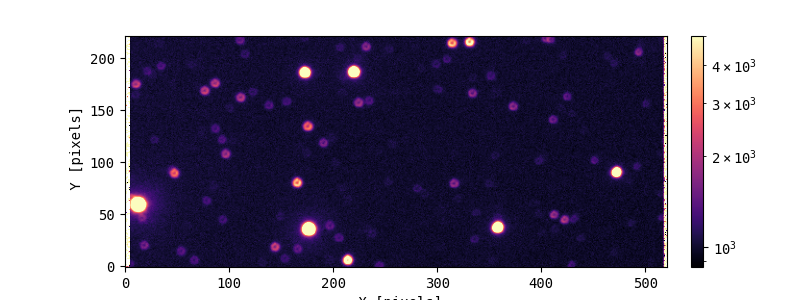

In [31]:
def make_ring_around_star(x_pos, y_pos, label='', color='w'):
    from matplotlib.patches import Circle

    n, radii = 50, [13, 20]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=0.5, label=label)

def make_ring_around_ref01_star(x_pos, y_pos, label='', color='w'):
    from matplotlib.patches import Circle

    n, radii = 50, [12, 19]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=0.5, label=label)


def make_ring_around_ref02_star(x_pos, y_pos, label='', color='w'):
    from matplotlib.patches import Circle

    n, radii = 50, [11, 17]
    theta = np.linspace(0, 2*np.pi, n, endpoint=True)
    xs = np.outer(radii, np.cos(theta))
    ys = np.outer(radii, np.sin(theta))
    
    # in order to have a closed area, the circles
    # should be traversed in opposite directions
    xs[1,:] = xs[1,::-1]
    ys[1,:] = ys[1,::-1]
    
    ax.fill(np.ravel(xs)+x_pos, np.ravel(ys)+y_pos, edgecolor=None, facecolor=color, alpha=0.5, label=label)


vmin = np.amin(science_corrected[:,100:400])
vmax = np.amax(science_corrected[:,100:400])
print('vmin:  {0:.1f}    vmax: {1:.1f}'.format(vmin, vmax))
vmax = 5000

fig, ax = plt.subplots(1, figsize=(8,3))
im1 = plt.imshow(science_corrected, cmap=plt.colormaps['magma'], norm=colors.LogNorm(vmin=vmin, vmax=vmax), origin='lower')
plt.colorbar(im1,ax=ax, fraction=0.046, pad=0.04)

#make_ring_around_star(x_target_refined, y_target_refined, label='Target', color='w')
#make_ring_around_ref01_star(x_ref01_refined, y_ref01_refined, label='Reference #1', color='y')
#make_ring_around_ref02_star(x_ref02_refined, y_ref02_refined, label='Reference #2', color='y')
plt.xlabel(' X [pixels]')
plt.ylabel(' Y [pixels]')
#ax.legend()
plt.show()

/tmp/ipykernel_60400/233329921.py:9: RuntimeWarning: invalid value encountered in multiply
  target_total_flux = np.nansum(science_corrected*target_annulus_sel)
/tmp/ipykernel_60400/233329921.py:12: RuntimeWarning: invalid value encountered in multiply
  target_flux_x = np.nansum(science_corrected*target_annulus_sel, axis=0)
/tmp/ipykernel_60400/233329921.py:13: RuntimeWarning: invalid value encountered in multiply
  target_flux_y = np.nansum(science_corrected*target_annulus_sel, axis=1)


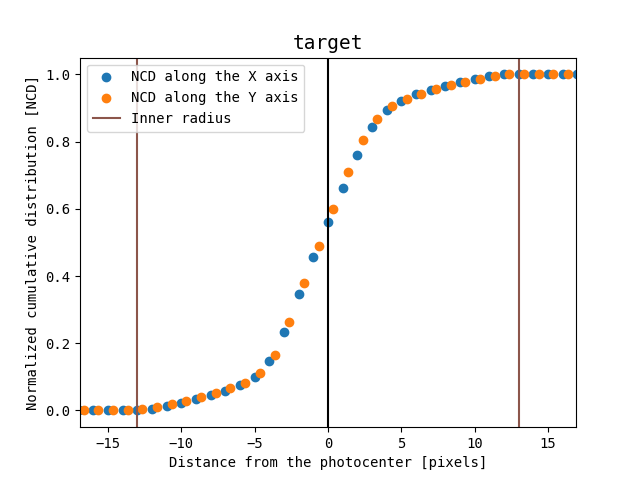

In [26]:
# flux within the annulus 
# 2D array with the distance of each pixel from the target star 
target_distance = np.sqrt((X-x_target_refined)**2 + (Y-y_target_refined)**2)

# Selection of the pixels within the inner radius
target_annulus_sel = (target_distance < target_inner_radius)

# We compute the sum of the total flux within the inner radius.
target_total_flux = np.nansum(science_corrected*target_annulus_sel) 

# We compute the sum of the flux along each axis, within the inner radius.
target_flux_x = np.nansum(science_corrected*target_annulus_sel, axis=0) 
target_flux_y = np.nansum(science_corrected*target_annulus_sel, axis=1) 

# we compute the cumulative sum along each axis, normalized to the total flux
target_cumulative_sum_x = np.cumsum(target_flux_x)/target_total_flux
target_cumulative_sum_y = np.cumsum(target_flux_y)/target_total_flux

plt.figure()
plt.scatter(X_axis-x_target_refined,target_cumulative_sum_x, label='NCD along the X axis')
plt.scatter(Y_axis-y_target_refined,target_cumulative_sum_y, label='NCD along the Y axis')
plt.axvline(0, c='k')

plt.xlim(-target_inner_radius*1.3, target_inner_radius*1.3)

plt.axvline(target_inner_radius, c='C5', label='Inner radius') 
plt.axvline(-target_inner_radius, c='C5')
plt.xlabel('Distance from the photocenter [pixels]')
plt.ylabel('Normalized cumulative distribution [NCD]')
plt.title('target')
plt.legend()

plt.show()

/tmp/ipykernel_60400/1237396952.py:9: RuntimeWarning: invalid value encountered in multiply
  reference_01_total_flux = np.nansum(science_corrected*reference_01_annulus_sel)
/tmp/ipykernel_60400/1237396952.py:12: RuntimeWarning: invalid value encountered in multiply
  reference_01_flux_x = np.nansum(science_corrected*reference_01_annulus_sel, axis=0)
/tmp/ipykernel_60400/1237396952.py:13: RuntimeWarning: invalid value encountered in multiply
  reference_01_flux_y = np.nansum(science_corrected*reference_01_annulus_sel, axis=1)


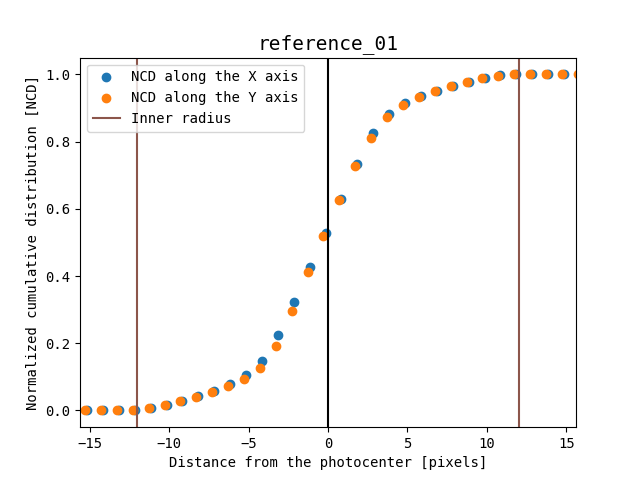

In [27]:
# flux within the annulus 
# 2D array with the distance of each pixel from the reference_01 star 
reference_01_distance = np.sqrt((X-x_reference_01_refined)**2 + (Y-y_reference_01_refined)**2)

# Selection of the pixels within the inner radius
reference_01_annulus_sel = (reference_01_distance < reference_01_inner_radius)

# We compute the sum of the total flux within the inner radius.
reference_01_total_flux = np.nansum(science_corrected*reference_01_annulus_sel) 

# We compute the sum of the flux along each axis, within the inner radius.
reference_01_flux_x = np.nansum(science_corrected*reference_01_annulus_sel, axis=0) 
reference_01_flux_y = np.nansum(science_corrected*reference_01_annulus_sel, axis=1) 

# we compute the cumulative sum along each axis, normalized to the total flux
reference_01_cumulative_sum_x = np.cumsum(reference_01_flux_x)/reference_01_total_flux
reference_01_cumulative_sum_y = np.cumsum(reference_01_flux_y)/reference_01_total_flux

plt.figure()
plt.scatter(X_axis-x_reference_01_refined,reference_01_cumulative_sum_x, label='NCD along the X axis')
plt.scatter(Y_axis-y_reference_01_refined,reference_01_cumulative_sum_y, label='NCD along the Y axis')
plt.axvline(0, c='k')

plt.xlim(-reference_01_inner_radius*1.3, reference_01_inner_radius*1.3)

plt.axvline(reference_01_inner_radius, c='C5', label='Inner radius') 
plt.axvline(-reference_01_inner_radius, c='C5')
plt.xlabel('Distance from the photocenter [pixels]')
plt.ylabel('Normalized cumulative distribution [NCD]')
plt.title('reference_01')
plt.legend()

plt.show()

/tmp/ipykernel_60400/1753607418.py:9: RuntimeWarning: invalid value encountered in multiply
  reference_02_total_flux = np.nansum(science_corrected*reference_02_annulus_sel)
/tmp/ipykernel_60400/1753607418.py:12: RuntimeWarning: invalid value encountered in multiply
  reference_02_flux_x = np.nansum(science_corrected*reference_02_annulus_sel, axis=0)
/tmp/ipykernel_60400/1753607418.py:13: RuntimeWarning: invalid value encountered in multiply
  reference_02_flux_y = np.nansum(science_corrected*reference_02_annulus_sel, axis=1)


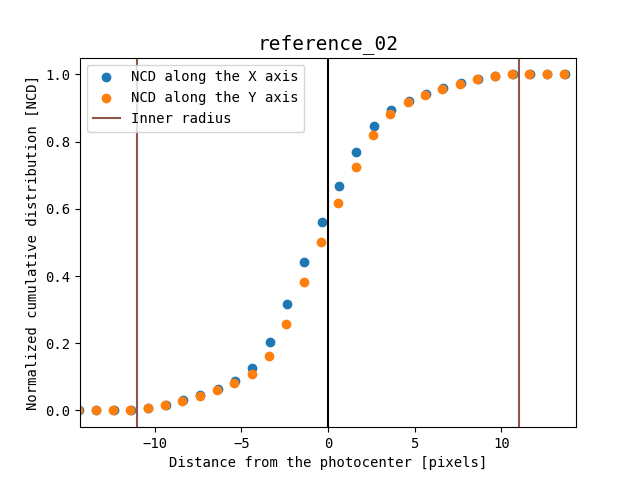

In [28]:
# flux within the annulus 
# 2D array with the distance of each pixel from the reference_02 star 
reference_02_distance = np.sqrt((X-x_reference_02_refined)**2 + (Y-y_reference_02_refined)**2)

# Selection of the pixels within the inner radius
reference_02_annulus_sel = (reference_02_distance < reference_02_inner_radius)

# We compute the sum of the total flux within the inner radius.
reference_02_total_flux = np.nansum(science_corrected*reference_02_annulus_sel) 

# We compute the sum of the flux along each axis, within the inner radius.
reference_02_flux_x = np.nansum(science_corrected*reference_02_annulus_sel, axis=0) 
reference_02_flux_y = np.nansum(science_corrected*reference_02_annulus_sel, axis=1) 

# we compute the cumulative sum along each axis, normalized to the total flux
reference_02_cumulative_sum_x = np.cumsum(reference_02_flux_x)/reference_02_total_flux
reference_02_cumulative_sum_y = np.cumsum(reference_02_flux_y)/reference_02_total_flux

plt.figure()
plt.scatter(X_axis-x_reference_02_refined,reference_02_cumulative_sum_x, label='NCD along the X axis')
plt.scatter(Y_axis-y_reference_02_refined,reference_02_cumulative_sum_y, label='NCD along the Y axis')
plt.axvline(0, c='k')

plt.xlim(-reference_02_inner_radius*1.3, reference_02_inner_radius*1.3)

plt.axvline(reference_02_inner_radius, c='C5', label='Inner radius') 
plt.axvline(-reference_02_inner_radius, c='C5')
plt.xlabel('Distance from the photocenter [pixels]')
plt.ylabel('Normalized cumulative distribution [NCD]')
plt.title('reference_02')
plt.legend()

plt.show()

In [29]:
def determine_FWHM_axis(reference_axis, normalized_cumulative_distribution):
    
    # Find the closest point to NCD= 0.15865 (-1 sigma)
    NCD_index_left = np.argmin(np.abs(normalized_cumulative_distribution-0.15865))
    
    # Find the closest point to NCD= 0.84135 (+1 sigma)
    NCD_index_right = np.argmin(np.abs(normalized_cumulative_distribution-0.84135))

    # We model the NCD around the -1sgima value with a polynomial curve. 
    # The independet variable is actually the normalized cumulative distribution, 
    # the depedent variable is the pixel position
    p_fitted = np.polynomial.Polynomial.fit(normalized_cumulative_distribution[NCD_index_left-1: NCD_index_left+2],
                                            reference_axis[NCD_index_left-1: NCD_index_left+2],
                                            deg=2)

    # We get a more precise estimate of the pixel value corresponding to the -1sigma position
    pixel_left = p_fitted(0.15865)

    # We repeat the step for the 1sigma value
    p_fitted = np.polynomial.Polynomial.fit(normalized_cumulative_distribution[NCD_index_right-1: NCD_index_right+2],
                                            reference_axis[NCD_index_right-1: NCD_index_right+2],
                                            deg=2)
    pixel_right = p_fitted(0.84135)

    print(pixel_left, pixel_right)
    
    FWHM_factor = 2 * np.sqrt(2 * np.log(2)) # = 2.35482
    FWHM = (pixel_right-pixel_left)/2. * FWHM_factor

    return FWHM
    

In [30]:
print('target')
target_FWHM_x = determine_FWHM_axis(X_axis, target_cumulative_sum_x)
target_FWHM_y = determine_FWHM_axis(Y_axis, target_cumulative_sum_y)
print('FWHM along the X axis: {0:.2f}'.format(target_FWHM_x)) 
print('FWHM along the Y axis: {0:.2f}'.format(target_FWHM_y))
print('Seeing along the X axis (after defocusing): {0:.2f}'.format(target_FWHM_x* 4*0.25)) 
print('Seeing along the Y axis (after defocusing): {0:.2f}'.format(target_FWHM_y* 4*0.25))  
print('--------')
print('ref 01')
reference_01_FWHM_x = determine_FWHM_axis(X_axis, reference_01_cumulative_sum_x)
reference_01_FWHM_y = determine_FWHM_axis(Y_axis, reference_01_cumulative_sum_y)
print('FWHM along the X axis: {0:.2f}'.format(reference_01_FWHM_x)) 
print('FWHM along the Y axis: {0:.2f}'.format(reference_01_FWHM_y)) 
print('Seeing along the X axis (after defocusing): {0:.2f}'.format(reference_01_FWHM_x* 4*0.25)) 
print('Seeing along the Y axis (after defocusing): {0:.2f}'.format(reference_01_FWHM_y* 4*0.25))  
print('-------')
print('ref 02')
reference_02_FWHM_x = determine_FWHM_axis(X_axis, reference_02_cumulative_sum_x)
reference_02_FWHM_y = determine_FWHM_axis(Y_axis, reference_02_cumulative_sum_y)
print('FWHM along the X axis: {0:.2f}'.format(reference_02_FWHM_x)) 
print('FWHM along the Y axis: {0:.2f}'.format(reference_02_FWHM_y)) 
print('Seeing along the X axis (after defocusing): {0:.2f}'.format(reference_02_FWHM_x* 4*0.25)) 
print('Seeing along the Y axis (after defocusing): {0:.2f}'.format(reference_02_FWHM_y* 4*0.25))  
print('-------')

target
353.1956763206489 359.94000863458723
33.91637454539296 40.4556982417278
FWHM along the X axis: 7.94
FWHM along the Y axis: 7.70
Seeing along the X axis (after defocusing): 7.94
Seeing along the Y axis (after defocusing): 7.70
--------
ref 01
168.19263654687717 175.25698429725952
182.6504744717122 189.45662865269838
FWHM along the X axis: 8.32
FWHM along the Y axis: 8.01
Seeing along the X axis (after defocusing): 8.32
Seeing along the Y axis (after defocusing): 8.01
-------
ref 02
467.56697860712876 473.9192879785693
86.96512562704476 93.33013959040184
FWHM along the X axis: 7.48
FWHM along the Y axis: 7.49
Seeing along the X axis (after defocusing): 7.48
Seeing along the Y axis (after defocusing): 7.49
-------


In [63]:
# From the fits header of the first image:
# CCDSCALE=                 0.25 / [arcsec/px] unbinned CCD camera scale
#BINX    =                    4 / Horizontal Binning factor used
#BINY    =                    4 / Vertical Binning factor used
